<h2 style="text-align: center; font-family: Arial, sans-serif; font-weight: bold; color: #2c3e50; text-transform: uppercase; margin: 20px 0;">Freshness Inspection at FreshHarvest using CNN </h2>

<h2 style="text-align: center; font-family: Arial, sans-serif; font-weight: bold; color: #2c3e50; text-transform: uppercase; margin: 20px 0;">Freshness Inspection at FreshHarvest using CNN </h2>

#### Importing all Libraries

In [2]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import torchvision.models as models
from matplotlib import pyplot as plt

#### Data Load and Transformation

In [3]:
image_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  #These values are calculated per channel (Red, Green, Blue) and are derived from the ImageNet training dataset
])

In [4]:
dataset_path = "./FRUIT-16K"

dataset = datasets.ImageFolder(root=dataset_path, transform=image_transforms)
len(dataset)

16000

In [5]:
class_names = dataset.classes
class_names # 16 classes for the output

['F_Banana',
 'F_Lemon',
 'F_Lulo',
 'F_Mango',
 'F_Orange',
 'F_Strawberry',
 'F_Tamarillo',
 'F_Tomato',
 'S_Banana',
 'S_Lemon',
 'S_Lulo',
 'S_Mango',
 'S_Orange',
 'S_Strawberry',
 'S_Tamarillo',
 'S_Tomato']

In [6]:
num_classes = len(dataset.classes)
num_classes

16

#### Splitting the Data: 75% Training, 25% Testing

In [7]:
train_size = int(0.75*len(dataset))
val_size = len(dataset) - train_size

train_size, val_size

(12000, 4000)

In [8]:
from torch.utils.data import random_split

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [9]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [10]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [11]:
labels[31]  #Fresh Banana

tensor(7)

In [12]:
images[4].shape

torch.Size([3, 224, 224])

In [13]:
images[4].permute(1,2,0).shape

torch.Size([224, 224, 3])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8267832..2.3959913].


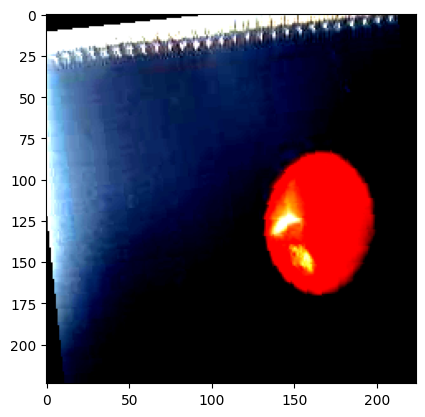

In [14]:
plt.imshow(images[31].permute(1,2,0))
plt.show()

#### Model 1: CNN

In [15]:
class FruitClassifierCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels = 3,out_channels = 16,kernel_size = 3,stride = 1,padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (16, 112, 112),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (32, 56, 56)           
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (64, 28, 28),
            nn.Flatten(),
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.network(x)
        return x

In [18]:
def train_model(model, criterion, optimizer, epochs=1):
    start = time.time()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num, (images, labels) in enumerate(train_loader):
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
            if (batch_num+1) % 10 == 0:
                print(f"Batch: {batch_num+1}, Epoch: {epoch+1}, Loss: {loss.item():0.2f}")
            
            running_loss += loss.item() * images.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}], Avg Loss: {epoch_loss:.4f}")

        # Validation
        model.eval()
        correct = 0
        total = 0
        all_labels = []
        all_predictions = []
        
        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images)
                _, predicted = torch.max(outputs.data,1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())
                
            print(f"*** Validation Accuracy: {100 * correct / total:.2f}% ***")
            
    end = time.time()
    print(f"Execution time: {end - start} seconds")     
    
    return all_labels, all_predictions

In [23]:
# Instantiate the model, loss function, and optimizer
model = FruitClassifierCNN(num_classes=num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

all_labels, all_predictions = train_model(model, criterion, optimizer, epochs=10)

Batch: 10, Epoch: 1, Loss: 2.76
Batch: 20, Epoch: 1, Loss: 2.76
Batch: 30, Epoch: 1, Loss: 2.79
Batch: 40, Epoch: 1, Loss: 2.48
Batch: 50, Epoch: 1, Loss: 2.30
Batch: 60, Epoch: 1, Loss: 2.07
Batch: 70, Epoch: 1, Loss: 1.89
Batch: 80, Epoch: 1, Loss: 1.77
Batch: 90, Epoch: 1, Loss: 1.30
Batch: 100, Epoch: 1, Loss: 1.63
Batch: 110, Epoch: 1, Loss: 1.51
Batch: 120, Epoch: 1, Loss: 1.47
Batch: 130, Epoch: 1, Loss: 1.47
Batch: 140, Epoch: 1, Loss: 1.19
Batch: 150, Epoch: 1, Loss: 0.82
Batch: 160, Epoch: 1, Loss: 1.21
Batch: 170, Epoch: 1, Loss: 1.11
Batch: 180, Epoch: 1, Loss: 1.35
Batch: 190, Epoch: 1, Loss: 1.01
Batch: 200, Epoch: 1, Loss: 1.10
Batch: 210, Epoch: 1, Loss: 0.89
Batch: 220, Epoch: 1, Loss: 0.83
Batch: 230, Epoch: 1, Loss: 1.02
Batch: 240, Epoch: 1, Loss: 1.01
Batch: 250, Epoch: 1, Loss: 1.35
Batch: 260, Epoch: 1, Loss: 0.62
Batch: 270, Epoch: 1, Loss: 0.54
Batch: 280, Epoch: 1, Loss: 1.00
Batch: 290, Epoch: 1, Loss: 0.93
Batch: 300, Epoch: 1, Loss: 0.74
Batch: 310, Epoch: 

### Training And Validation Accuracy

#### Model 2:CNN with batch norm, weight decay, early stopping, dropout regularization

In [22]:
from sklearn.metrics import accuracy_score

In [16]:
class FreshnessClassifierCNN2(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),  # (16, 112, 112)
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),  # (32, 56, 56)           
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),  # (64, 28, 28)
            nn.Flatten(),
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        x = self.network(x)
        return x  

In [18]:
# Training function
def train_model_early_stop(model, train_loader, val_loader, criterion, optimizer, epochs=15):
    
    patience = 3
    best_accuracy = 0
    counter = 0
    
    train_losses, val_losses, val_accuracies = [], [], []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for batch_num, (images, labels) in enumerate(train_loader):
            optimizer.zero_grad()
            outputs = model(images)  # ✅ FIXED: changed 'inputs' to 'images'
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
            if (batch_num+1) % 10 == 0:
                print(f"Batch: {batch_num+1}, Epoch: {epoch+1}, Loss: {loss.item():.2f}")
                
        train_losses.append(running_loss / len(train_loader))
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        y_pred, y_true = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                y_pred.extend(predicted.cpu().numpy())
                y_true.extend(labels.cpu().numpy())
        val_losses.append(val_loss / len(val_loader))
        val_accuracy = accuracy_score(y_true, y_pred)
        val_accuracies.append(val_accuracy)
        
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Val Accuracy: {val_accuracy:.4f}")
    
        
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            counter = 0
            torch.save(model.state_dict(), "best_model.pt")
        else:
            counter += 1
            if counter >= patience:
                print(f"Early Stopping at Epoch {epoch+1}")
                break
    
    return train_losses, val_losses, val_accuracies

Batch: 10, Epoch: 1, Loss: 2.77
Batch: 20, Epoch: 1, Loss: 2.80
Batch: 30, Epoch: 1, Loss: 2.76
Batch: 40, Epoch: 1, Loss: 2.77
Batch: 50, Epoch: 1, Loss: 2.80
Batch: 60, Epoch: 1, Loss: 2.80
Batch: 70, Epoch: 1, Loss: 2.69
Batch: 80, Epoch: 1, Loss: 2.79
Batch: 90, Epoch: 1, Loss: 2.78
Batch: 100, Epoch: 1, Loss: 2.77
Batch: 110, Epoch: 1, Loss: 2.76
Batch: 120, Epoch: 1, Loss: 2.73
Batch: 130, Epoch: 1, Loss: 2.73
Batch: 140, Epoch: 1, Loss: 2.74
Batch: 150, Epoch: 1, Loss: 2.74
Batch: 160, Epoch: 1, Loss: 2.68
Batch: 170, Epoch: 1, Loss: 2.70
Batch: 180, Epoch: 1, Loss: 2.73
Batch: 190, Epoch: 1, Loss: 2.71
Batch: 200, Epoch: 1, Loss: 2.64
Batch: 210, Epoch: 1, Loss: 2.56
Batch: 220, Epoch: 1, Loss: 2.37
Batch: 230, Epoch: 1, Loss: 2.35
Batch: 240, Epoch: 1, Loss: 2.67
Batch: 250, Epoch: 1, Loss: 2.56
Batch: 260, Epoch: 1, Loss: 2.51
Batch: 270, Epoch: 1, Loss: 2.31
Batch: 280, Epoch: 1, Loss: 2.74
Batch: 290, Epoch: 1, Loss: 2.58
Batch: 300, Epoch: 1, Loss: 2.17
Batch: 310, Epoch: 

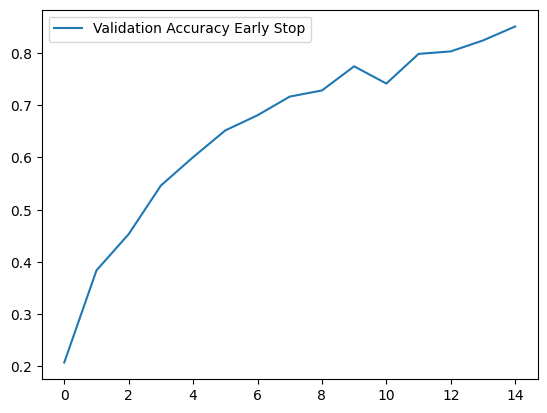

In [23]:
model = FreshnessClassifierCNN2(num_classes=num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

train_losses, val_losses, val_accuracies = train_model_early_stop(
    model, train_loader, val_loader, criterion, optimizer, epochs=15
)
plt.plot(val_accuracies, label="Validation Accuracy Early Stop")
plt.legend()
plt.show()

#### Model 3: Transfer Learning With Resnet50

In [17]:
# Load the pre-trained ResNet model
class FruitFreshnessClassifier(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super().__init__()
        self.model = models.resnet50(weights='DEFAULT')
        # Freeze all layers except the final fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False
            
        # Unfreeze layer4 and fc layers
        for param in self.model.layer4.parameters():
            param.requires_grad = True            
            
        # Replace the final fully connected layer
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.model.fc.in_features, num_classes)
        )

    def forward(self, x):
        x = self.model(x)
        return x

In [19]:
model = FruitFreshnessClassifier(num_classes=num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

labels, predictions = train_model(model, criterion, optimizer, epochs=1)

Batch: 10, Epoch: 1, Loss: 1.47
Batch: 20, Epoch: 1, Loss: 0.37
Batch: 30, Epoch: 1, Loss: 0.11
Batch: 40, Epoch: 1, Loss: 0.16
Batch: 50, Epoch: 1, Loss: 0.14
Batch: 60, Epoch: 1, Loss: 0.02
Batch: 70, Epoch: 1, Loss: 0.03
Batch: 80, Epoch: 1, Loss: 0.17
Batch: 90, Epoch: 1, Loss: 0.19
Batch: 100, Epoch: 1, Loss: 0.08
Batch: 110, Epoch: 1, Loss: 0.02
Batch: 120, Epoch: 1, Loss: 0.04
Batch: 130, Epoch: 1, Loss: 0.06
Batch: 140, Epoch: 1, Loss: 0.03
Batch: 150, Epoch: 1, Loss: 0.07
Batch: 160, Epoch: 1, Loss: 0.23
Batch: 170, Epoch: 1, Loss: 0.06
Batch: 180, Epoch: 1, Loss: 0.07
Batch: 190, Epoch: 1, Loss: 0.06
Batch: 200, Epoch: 1, Loss: 0.16
Batch: 210, Epoch: 1, Loss: 0.05
Batch: 220, Epoch: 1, Loss: 0.05
Batch: 230, Epoch: 1, Loss: 0.01
Batch: 240, Epoch: 1, Loss: 0.06
Batch: 250, Epoch: 1, Loss: 0.03
Batch: 260, Epoch: 1, Loss: 0.05
Batch: 270, Epoch: 1, Loss: 0.02
Batch: 280, Epoch: 1, Loss: 0.09
Batch: 290, Epoch: 1, Loss: 0.01
Batch: 300, Epoch: 1, Loss: 0.08
Batch: 310, Epoch: 

In [20]:
from sklearn.metrics import classification_report

report = classification_report(labels, predictions)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       261
           1       0.96      1.00      0.98       243
           2       1.00      1.00      1.00       257
           3       1.00      1.00      1.00       248
           4       1.00      1.00      1.00       273
           5       1.00      1.00      1.00       252
           6       1.00      0.99      1.00       264
           7       1.00      1.00      1.00       243
           8       1.00      0.99      1.00       229
           9       1.00      0.96      0.98       255
          10       1.00      1.00      1.00       234
          11       1.00      1.00      1.00       260
          12       1.00      1.00      1.00       257
          13       1.00      1.00      1.00       261
          14       0.99      1.00      1.00       226
          15       1.00      1.00      1.00       237

    accuracy                           1.00      4000
   macro avg       1.00   

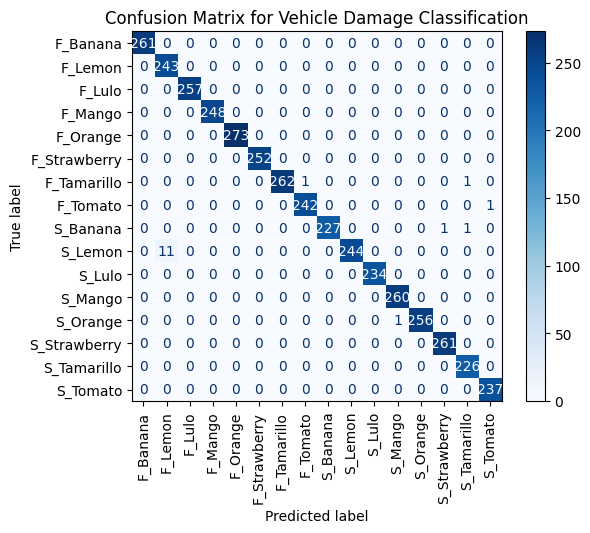

In [22]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

conf_matrix = confusion_matrix(labels, predictions, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=90)
plt.title("Confusion Matrix for Vehicle Damage Classification")
plt.show()

In [24]:
torch.save(model.state_dict(), 'model/freshness_resnet50.pth')